# Component classifier on Kaggle

Trains and evaluates the symbol-crop classifier in `src/Object Detection/Component Training/` straight from the GitHub repo. All logic lives in the repo's `.py` files; this notebook only wires Kaggle paths to them.

**Before running**
- Settings → Accelerator: GPU. Settings → Internet: On (for `git` and `pip`).
- Attach the training crops dataset (`manifest.jsonl`, `classes.txt`, `images/train`, `images/val`).
- Optional: attach the CGHD hand-drawn test crops (`images/test`, `labels/test`; `manifest.jsonl` optional). The printed held-out test set ships with the repo, so nothing is downloaded by default.

Run top to bottom. Every cell is safe to re-run after a kernel restart.

In [4]:
# 1. Repo + data wiring
import os, shutil, subprocess, sys
from pathlib import Path

REPO_URL = "https://github.com/ishuu19/Single-Line-Diagram-and-Energy-Mapping.git"
REPO = Path("/kaggle/working/Single-Line-Diagram-and-Energy-Mapping")
TRAIN_DIR = REPO / "src" / "Object Detection" / "Component Training"
SAVE_DIR = Path("/kaggle/working/component_train_outputs")   # survives "Save Version"
INPUT = Path("/kaggle/input")



In [5]:
def sh(*cmd, cwd=None):
    r = subprocess.run(cmd, cwd=cwd, text=True, capture_output=True)
    print((r.stdout + r.stderr).strip() or f"$ {' '.join(cmd)}")
    return r.returncode

if (REPO / ".git").is_dir():
    sh("git", "pull", "--ff-only", cwd=REPO)
else:
    sh("git", "clone", "-q", REPO_URL, str(REPO))
assert (TRAIN_DIR / "train.py").exists(), TRAIN_DIR

def find_dir(marker: str):
    """First directory under /kaggle/input containing `marker` (a relative path like images/train)."""
    for hit in INPUT.rglob(marker.split("/")[-1]):
        root = hit
        for _ in marker.split("/"):
            root = root.parent
        if (root / marker).exists():
            return root
    return None

def link(src: Path, dest: Path):
    if dest.is_symlink() or dest.exists():
        dest.unlink() if dest.is_symlink() else shutil.rmtree(dest)
    os.symlink(src, dest, target_is_directory=True)

sys.path.insert(0, str(TRAIN_DIR))
import config  # dataset paths live here (REPO/Data/...)
config.DATA_ROOT.mkdir(exist_ok=True)



$ git clone -q https://github.com/ishuu19/Single-Line-Diagram-and-Energy-Mapping.git /kaggle/working/Single-Line-Diagram-and-Energy-Mapping


In [6]:
# training crops (read-only is fine -> symlink). The attached dataset has images/train + manifest.jsonl
SYMBOLS = find_dir("images/train")
assert SYMBOLS and (SYMBOLS / "manifest.jsonl").exists(), "training crops dataset not attached"
link(SYMBOLS, config.DATA_DIR)

# printed held-out test set: committed as a zip, unpack it next to the other data
zip_path = config.DATA_ROOT / "component-symbols-test-printed.zip"
if not (config.PRINTED_TEST_DATA_DIR / "images" / "test").is_dir() and zip_path.exists():
    import zipfile
    with zipfile.ZipFile(zip_path) as z:
        names = z.namelist()
        # accept both "images/test/..." and "component-symbols-test-printed/images/test/..." layouts
        target = config.DATA_ROOT if names and names[0].startswith("component-symbols-test-printed/") else config.PRINTED_TEST_DATA_DIR
        z.extractall(target)

# CGHD hand-drawn crops: normalisation rewrites them, and /kaggle/input is read-only -> copy
TEST_DEST = config.TEST_DATA_DIR
TEST_SRC = next((d for d in (find_dir("labels/test"),) if d and "printed" not in str(d)), None)
if TEST_SRC and not TEST_DEST.exists():
    shutil.copytree(TEST_SRC, TEST_DEST)

# bring back models from an earlier session of this notebook
if (SAVE_DIR / "models").exists():
    (TRAIN_DIR / "models").mkdir(exist_ok=True)
    for f in (SAVE_DIR / "models").glob("*.keras"):
        if not (TRAIN_DIR / "models" / f.name).exists():
            shutil.copy(f, TRAIN_DIR / "models" / f.name)

os.chdir(TRAIN_DIR)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "keras-tuner", "huggingface_hub"], check=True)



CompletedProcess(args=['/usr/bin/python3', '-m', 'pip', 'install', '-q', 'keras-tuner', 'huggingface_hub'], returncode=0)

In [7]:
import tensorflow as tf
print("train crops:", SYMBOLS)
print("printed    :", "ok" if (config.PRINTED_TEST_DATA_DIR / "images" / "test").is_dir() else "missing")
print("cghd crops :", TEST_SRC or "not attached")
print("models     :", sorted(p.name for p in (TRAIN_DIR / "models").glob("*.keras")))
print("TF", tf.__version__, "| GPU:", tf.config.list_physical_devices("GPU"))

train crops: /kaggle/input/datasets/anayedeshan/sld-component-dataset/component-symbols
printed    : ok
cghd crops : not attached
models     : ['notebook_best.keras']
TF 2.20.0 | GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


## 2. Data check
`data.py` reads the `train` / `val` splits from `manifest.jsonl`, inverts, pads to 128×128 and one-hot encodes. Expect 66 classes, 99,000 train and 1,000 test crops (the 1,000 test crops double as validation because the set has no `val` split).

In [8]:
import os
import sys
from pathlib import Path

REPO = Path("/kaggle/working/Single-Line-Diagram-and-Energy-Mapping")
TRAIN_DIR = REPO / "src" / "Object Detection" / "Component Training"

if not (TRAIN_DIR / "config.py").is_file():
    raise FileNotFoundError(
        "config.py not found. Run the «1. Repo + data wiring» cell first "
        "(git clone/pull + attach training crops + symlink to Data/component-symbols)."
    )

if str(TRAIN_DIR) not in sys.path:
    sys.path.insert(0, str(TRAIN_DIR))
os.chdir(TRAIN_DIR)

from config import DEFAULT_HP, DATA_DIR
from data import load_datasets

train_ds, val_ds, class_names, class_weights = load_datasets(
    mixup_alpha=DEFAULT_HP["mixup_alpha"]
)
print("DATA_DIR:", DATA_DIR)
print("classes:", len(class_names))
print("train batches:", int(train_ds.cardinality()), "| val batches:", int(val_ds.cardinality()))
print("class weights all 1.0:", all(abs(w - 1.0) < 1e-6 for w in class_weights.values()))

I0000 00:00:1790491860.766961      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13756 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790491860.769668      58 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13756 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


DATA_DIR: /kaggle/working/Single-Line-Diagram-and-Energy-Mapping/Data/component-symbols
classes: 66
train batches: 3096 | val batches: 32
class weights all 1.0: False


## 3. Train
Warmup + cosine decay over `EPOCHS`, per-sample `RandomDegrade`, MixUp, label smoothing, AdamW. Writes `models/custom.keras`, `models/custom_best.keras`, `outputs/custom_history.csv`, `logs/custom/`. With 99k crops an epoch is ~3 min on a P100, so start with `EPOCHS = 30`. Set `EPOCHS = 3` for a smoke test.

Skip this cell to evaluate the committed checkpoint `models/notebook_best.keras` instead.

In [11]:
EPOCHS = 30
!python train.py --epochs {EPOCHS}

I0000 00:00:1790492030.500997     183 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13620 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790492030.503193     183 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
Epoch 1/30
3096/3096 ━━━━━━━━━━━━━━━━━━━━ 808s 77ms/step - accuracy: 0.0917 - loss: 3.8689 - top3: 0.1998 - val_accuracy: 0.1650 - val_loss: 3.3574 - val_top3: 0.3440
Epoch 2/30
3096/3096 ━━━━━━━━━━━━━━━━━━━━ 224s 72ms/step - accuracy: 0.4881 - loss: 2.5823 - top3: 0.7133 - val_accuracy: 0.8270 - val_loss: 1.3998 - val_top3: 0.9550
Epoch 3/30
3096/3096 ━━━━━━━━━━━━━━━━━━━━ 224s 72ms/step - accuracy: 0.7826 - loss: 1.8706 - top3: 0.9118 - val_accuracy: 0.9530 - val_loss: 1.0202 - val_top3: 0.9930
Epoch 4/30
3096/3096 ━━━━━━━━━━━━━━━━━━━━ 225s 73ms/step 

## 4. Evaluate: val, printed held-out test, then CGHD hand-drawn test
`evaluate.py` reports clean / TTA / degraded accuracy plus a classification report and confusion matrix for each split.

- `val`: Schematex crops in the training style.
- `printed-test`: 198 crops (3 per type, 66 types) in `component-symbols-test-printed/` (in the repo) rendered with fonts, stroke widths, paper tints, scales, a 180° orientation and zoom the model never saw. Printed, not hand drawn. This is the first real generalisation number.
- `cghd-test`: only if the CGHD dataset is attached, or `FETCH_CGHD_SUBSET = True` (downloads 20 random sheets out of the first 100, not the whole dataset). Scored raw, then after `normalise_test_crops.py`.

In [12]:
import json, os, random
from pathlib import Path
from IPython.display import Image as IPyImage, display

FETCH_CGHD_SUBSET = False   # True: fetch 20 random CGHD sheets from the first 100 on the Hub (needs Internet)

have = {p.stem for p in Path("models").glob("*.keras")}
MODEL_TAG = next(t for t in ("custom_best", "custom", "notebook_best") if t in have)
print("model:", MODEL_TAG, "| available:", sorted(have))

!python evaluate.py --model {MODEL_TAG} --split val
!python evaluate.py --model {MODEL_TAG} --split printed-test

if not (TEST_DEST / "images" / "test").is_dir() and FETCH_CGHD_SUBSET:
    try:
        from kaggle_secrets import UserSecretsClient
        os.environ["HF_TOKEN"] = UserSecretsClient().get_secret("HF_TOKEN")
    except Exception:
        pass
    from huggingface_hub import list_repo_files, hf_hub_download
    CGHD_LOCAL = Path("/kaggle/working/cghd_subset")
    files = list_repo_files("lowercaseonly/cghd", repo_type="dataset")
    images = sorted(f for f in files if "/images/" in f and f.lower().endswith((".jpg", ".jpeg", ".png")))[:100]
    for img in random.Random(0).sample(images, 20):
        ann = img.replace("/images/", "/annotations/").rsplit(".", 1)[0] + ".xml"
        for rel in (img, ann):
            hf_hub_download("lowercaseonly/cghd", rel, repo_type="dataset", local_dir=CGHD_LOCAL)
    !python build_cghd_test_crops.py --cghd-root {CGHD_LOCAL} --pad 0.12 --refresh

if (TEST_DEST / "images" / "test").is_dir():
    if not (TEST_DEST / "images" / "test_raw").is_dir():
        !python evaluate.py --model {MODEL_TAG} --split cghd-test --out-suffix _raw
    !python normalise_test_crops.py --preview 6
    !python evaluate.py --model {MODEL_TAG} --split cghd-test
    display(IPyImage("outputs/test_crops_normalised.png"))
else:
    print("CGHD crops not attached; skipped")

for tag in ("val", "printed_test", "cghd_test_raw", "cghd_test"):
    p = Path("outputs") / f"{MODEL_TAG}_{tag}_metrics.json"
    if p.exists():
        print(f"{tag:<14}", json.loads(p.read_text()))

model: custom_best | available: ['custom', 'custom_best', 'notebook_best']
I0000 00:00:1790499482.020763    1103 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13620 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1790499482.022963    1103 gpu_device.cc:2020] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13654 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5
{
  "clean": 0.998,
  "tta": 0.998,
  "degraded": 0.998
}
                      precision    recall  f1-score   support

             utility       1.00      1.00      1.00        16
           generator       1.00      1.00      1.00        16
               solar       1.00      1.00      1.00        16
                wind       1.00      1.00      1.00        16
                 ups       1.00      1.00      1.00        16
         transformer       1.00      1.00      1.00 

## 5. Look at the printed test predictions
Accuracy broken down by the style factor that changed (orientation, scale, font, paper), then a grid of examples (green = correct). Set `TEST_DIR = config.TEST_DATA_DIR` to inspect the CGHD crops instead.

accuracy: 0.934 on 198 crops
orientation  {0: '1.00 (n=49)', 180: '0.81 (n=57)', 270: '1.00 (n=40)', 90: '0.96 (n=52)'}
scale        {0.75: '0.91 (n=65)', 1.3: '0.94 (n=66)', 1.45: '0.96 (n=67)'}
font         {'"Courier New"': '1.00 (n=43)', '"Trebuchet MS"': '0.94 (n=33)', 'Candara': '0.93 (n=29)', 'Corbel': '0.91 (n=33)', 'Georgia': '0.83 (n=23)', 'Tahoma': '0.95 (n=37)'}
paper        {'#e8eef2': '0.93 (n=55)', '#ececec': '0.98 (n=41)', '#fbf6dc': '0.92 (n=51)', '#ffffff': '0.92 (n=51)'}
standard     {'ansi': '0.92 (n=111)', 'iec': '0.95 (n=87)'}


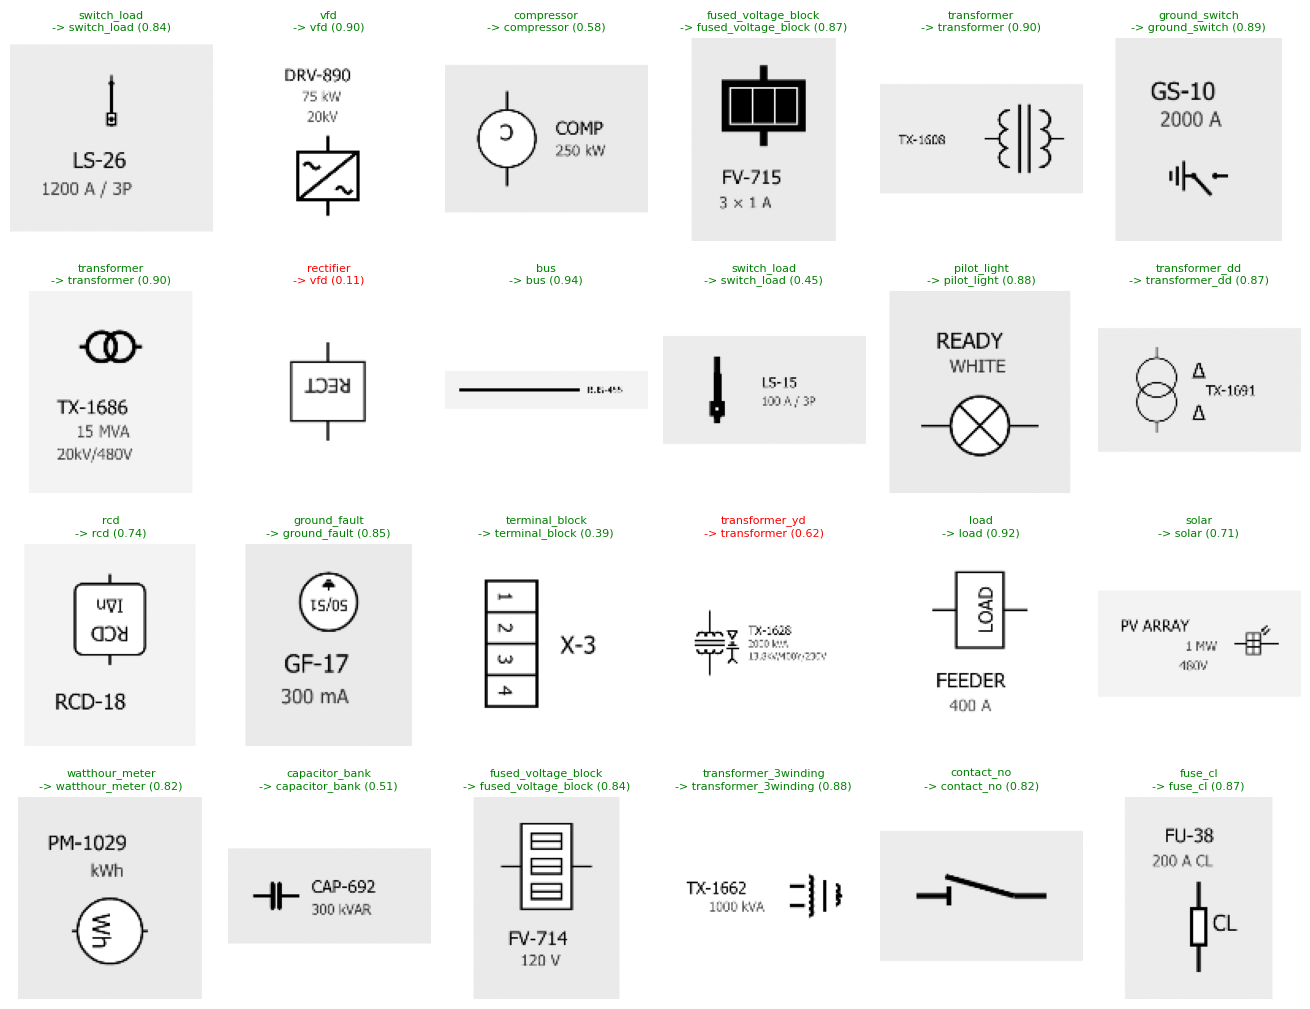

In [13]:
from collections import Counter
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import model as _  # registers RandomDegrade
import data, config

TEST_DIR = config.PRINTED_TEST_DATA_DIR
_, _, class_names, _ = data.load_datasets()
test_ds = data.load_external_test_dataset(class_names, TEST_DIR)
net = tf.keras.models.load_model(str(config.MODEL_DIR / f"{MODEL_TAG}.keras"), compile=False)

images, y_true, y_pred, conf = [], [], [], []
for x, y in test_ds:
    p = tf.nn.softmax(net(x, training=False), -1).numpy()
    images.append(x.numpy()); y_true.append(np.argmax(y.numpy(), -1))
    y_pred.append(np.argmax(p, -1)); conf.append(p.max(-1))
images, y_true, y_pred, conf = map(np.concatenate, (images, y_true, y_pred, conf))

ok = y_true == y_pred
print(f"accuracy: {ok.mean():.3f} on {len(y_true)} crops")
rows = [r for r in data.read_test_manifest(TEST_DIR) if r["type"] in class_names]
for key in ("orientation", "scale", "font", "paper", "standard"):
    if rows and key in rows[0]:
        by = {}
        for r, o in zip(rows, ok):
            by.setdefault(r[key], []).append(o)
        print(f"{key:<12}", {k: f"{np.mean(v):.2f} (n={len(v)})" for k, v in sorted(by.items(), key=str)})

n, cols = min(24, len(images)), 6
idx = np.random.RandomState(0).choice(len(images), n, replace=False)
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(2.2 * cols, 2.6 * rows), squeeze=False)
for ax, i in zip(axes.flat, idx):
    ax.imshow(255 - images[i].squeeze(), cmap="gray")
    ok = y_true[i] == y_pred[i]
    ax.set_title(f"{class_names[y_true[i]]}\n-> {class_names[y_pred[i]]} ({conf[i]:.2f})",
                 fontsize=8, color="green" if ok else "red")
for ax in axes.flat:
    ax.axis("off")
plt.tight_layout(); plt.show()

## 6. Keep the artefacts
Copies `models/`, `outputs/`, `logs/` to `/kaggle/working/component_train_outputs`, which Kaggle stores with the notebook version. Download `outputs/*_metrics.json` and `models/custom_best.keras` from there and commit them to the repo by hand.

In [14]:
for name in ("models", "outputs", "logs"):
    src = TRAIN_DIR / name
    if src.exists():
        shutil.copytree(src, SAVE_DIR / name, dirs_exist_ok=True)
print(sorted(str(p.relative_to(SAVE_DIR)) for p in SAVE_DIR.rglob("*") if p.is_file()))

['logs/custom/train/events.out.tfevents.1790492033.bfe0d231bfa1.183.0.v2', 'logs/custom/validation/events.out.tfevents.1790492834.bfe0d231bfa1.183.1.v2', 'logs/notebook/train/events.out.tfevents.1790404478.ISHUUUU.32600.0.v2', 'logs/notebook/train/events.out.tfevents.1790404583.ISHUUUU.32600.1.v2', 'logs/notebook/train/events.out.tfevents.1790405127.ISHUUUU.32600.2.v2', 'logs/notebook/validation/events.out.tfevents.1790405597.ISHUUUU.32600.3.v2', 'models/class_names.json', 'models/custom.keras', 'models/custom_best.keras', 'models/notebook_best.keras', 'outputs/custom_best_printed_test_confusion_matrix.png', 'outputs/custom_best_printed_test_metrics.json', 'outputs/custom_best_val_confusion_matrix.png', 'outputs/custom_best_val_metrics.json', 'outputs/custom_history.csv', 'outputs/custom_history.json', 'outputs/notebook_best_cghd_test_confusion_matrix.png', 'outputs/notebook_best_cghd_test_metrics.json', 'outputs/notebook_best_cghd_test_raw_confusion_matrix.png', 'outputs/notebook_best